# Benchmark Analysis Notebook

This notebook compares and visualizes performance for:
- BST (TreeSort with BST)
- RBBST (TreeSort with RBBST)
- QuickSort (unboxed)
- QuickSortBoxed (boxed)

Data design assumptions checked in this notebook:
- 20 arrays per distribution for each algorithm/structure
- each array result comes from 20 runs (`runs = 20`)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

def latex_escape(value):
    if pd.isna(value):
        return ''
    text = str(value)
    replacements = {
        '\\': '\\textbackslash{}',
        '_': '\\_',
        '%': '\\%',
        '&': '\\&',
        '#': '\\#',
        '$': '\\$',
        '{': '\\{',
        '}': '\\}',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    return text


def df_to_latex(df_in, caption, label, index=False, float_digits=3):
    df_work = df_in.copy()
    if not index:
        df_work = df_work.reset_index(drop=True)
    else:
        df_work = df_work.reset_index()

    headers = [latex_escape(col) for col in df_work.columns]
    col_spec = 'l' * len(headers)

    lines = [
        '\\begin{table}[htbp]',
        '\\centering',
        f'\\caption{{{latex_escape(caption)}}}',
        f'\\label{{{latex_escape(label)}}}',
        f'\\begin{{tabular}}{{{col_spec}}}',
        '\\hline',
        ' & '.join(headers) + ' \\\\',
        '\\hline',
    ]

    for _, row in df_work.iterrows():
        values = []
        for value in row.tolist():
            if pd.isna(value):
                values.append('')
            elif isinstance(value, (float, np.floating)):
                values.append(f'{value:.{float_digits}f}')
            else:
                values.append(latex_escape(value))
        lines.append(' & '.join(values) + ' \\\\')

    lines.extend([
        '\\hline',
        '\\end{tabular}',
        '\\end{table}',
    ])
    return '\n'.join(lines)

In [15]:
SORT_CSV = 'SortBench.csv'

sort_df = pd.read_csv(SORT_CSV)

for col in ['runs', 'height', 'min', 'max', 'mean', 'median', 'std', 'speedup']:
    if col in sort_df.columns:
        sort_df[col] = pd.to_numeric(sort_df[col], errors='coerce')

# Convert timing columns from nanoseconds to milliseconds for all downstream analysis.
time_cols = ['min', 'max', 'mean', 'median', 'std']
for col in time_cols:
    if col in sort_df.columns:
        sort_df[col] = sort_df[col] / 1_000_000

distribution_order = ['RANDOM', 'NEARLY_SORTED_10', 'NEARLY_SORTED_5', 'NEARLY_SORTED_1']

print('SortBench shape:', sort_df.shape)
print('SortBench distributions:', sorted(sort_df['distribution'].unique()))
print('Timing columns converted to milliseconds (ms).')

SortBench shape: (320, 11)
SortBench distributions: ['NEARLY_SORTED_1', 'NEARLY_SORTED_10', 'NEARLY_SORTED_5', 'RANDOM']
Timing columns converted to milliseconds (ms).


In [20]:
# Keep only the four main comparands from SortBench.
focus_df = sort_df[
    ((sort_df['operation'] == 'TreeSort') & (sort_df['dataStructure'].isin(['BST', 'RBBST']))) |
    ((sort_df['operation'] == 'QuickSort') & (sort_df['dataStructure'].isin(['QuickSort', 'QuickSortBoxed'])))
].copy()

label_map = {
    ('TreeSort', 'BST'): 'BST',
    ('TreeSort', 'RBBST'): 'RBBST',
    ('QuickSort', 'QuickSort'): 'QuickSort (Unboxed)',
    ('QuickSort', 'QuickSortBoxed'): 'QuickSort (Boxed)',
}
focus_df['algorithm'] = focus_df.apply(lambda r: label_map.get((r['operation'], r['dataStructure']), 'Other'), axis=1)

algorithm_order = ['BST', 'RBBST', 'QuickSort (Unboxed)', 'QuickSort (Boxed)']
focus_df['distribution'] = pd.Categorical(focus_df['distribution'], categories=distribution_order, ordered=True)
focus_df['algorithm'] = pd.Categorical(focus_df['algorithm'], categories=algorithm_order, ordered=True)

focus_df[['operation', 'distribution', 'dataStructure', 'algorithm', 'runs', 'mean']].head()

,operation,distribution,dataStructure,algorithm,runs,mean
0,TreeSort,RANDOM,BST,BST,20,43.213445
1,TreeSort,RANDOM,RBBST,RBBST,20,48.867600
2,QuickSort,RANDOM,QuickSort,QuickSort (Unboxed),20,9.562910
3,QuickSort,RANDOM,QuickSortBoxed,QuickSort (Boxed),20,24.648515
4,TreeSort,RANDOM,BST,BST,20,41.008115


In [21]:
# Validate the experimental design: 20 arrays per distribution per algorithm + runs=20.
checks = (
    focus_df.groupby(['distribution', 'algorithm'])
    .agg(
        arrays=('mean', 'size'),
        unique_runs=('runs', 'nunique'),
        min_runs=('runs', 'min'),
        max_runs=('runs', 'max')
    )
    .reset_index()
)

invalid_group_size = checks[checks['arrays'] != 20]
invalid_runs = checks[(checks['unique_runs'] != 1) | (checks['min_runs'] != 20) | (checks['max_runs'] != 20)]

print('Groups checked:', len(checks))
print('Invalid group size rows:', len(invalid_group_size))
print('Invalid runs rows:', len(invalid_runs))

if len(invalid_group_size) == 0 and len(invalid_runs) == 0:
    print('Design check passed: every distribution x algorithm group has 20 arrays and each row has runs=20.')
else:
    display(checks)
    display(invalid_group_size)
    display(invalid_runs)

checks

Groups checked: 16
Invalid group size rows: 0
Invalid runs rows: 0
Design check passed: every distribution x algorithm group has 20 arrays and each row has runs=20.


,distribution,algorithm,arrays,unique_runs,min_runs,max_runs
0,RANDOM,BST,20,1,20,20
1,RANDOM,RBBST,20,1,20,20
2,RANDOM,QuickSort (Unboxed),20,1,20,20
3,RANDOM,QuickSort (Boxed),20,1,20,20
4,NEARLY_SORTED_10,BST,20,1,20,20
5,NEARLY_SORTED_10,RBBST,20,1,20,20
6,NEARLY_SORTED_10,QuickSort (Unboxed),20,1,20,20
7,NEARLY_SORTED_10,QuickSort (Boxed),20,1,20,20
8,NEARLY_SORTED_5,BST,20,1,20,20
9,NEARLY_SORTED_5,RBBST,20,1,20,20


## Summary Statistics (Mean Time per Array)

`mean` is the average time in **milliseconds (ms)** from the 20-run benchmark for that array.
Lower values are better.

In [30]:
summary = (
    focus_df.groupby(['distribution', 'algorithm'])['mean']
    .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
    .reset_index()
    .sort_values(['distribution', 'mean'])
)

summary['cv_pct'] = (summary['std'] / summary['mean']) * 100
summary_pivot = summary.pivot(index='distribution', columns='algorithm', values='mean')

display(summary)
print('\nMean time pivot in milliseconds (ms), lower is better:')
display(summary_pivot)

summary_latex = df_to_latex(
    summary.round(3),
    caption='Summary statistics for per-array mean runtime by distribution and algorithm.',
    label='tab:sortbench_summary',
    index=False,
    float_digits=3,
)
pivot_latex = df_to_latex(
    summary_pivot.round(3),
    caption='Mean runtime pivot table in milliseconds.',
    label='tab:sortbench_mean_pivot',
    index=True,
    float_digits=3,
)
print('\nLaTeX for summary table:\n')
print(summary_latex)
print('\nLaTeX for mean-time pivot table:\n')
print(pivot_latex)

,distribution,algorithm,count,mean,median,std,min,max,cv_pct
2,RANDOM,QuickSort (Unboxed),20,9.756542,9.703700,0.166409,9.557690,9.964410,1.705618
3,RANDOM,QuickSort (Boxed),20,24.927670,25.030862,0.381568,24.194305,25.471375,1.530701
0,RANDOM,BST,20,40.810692,40.730267,0.766767,39.818320,43.213445,1.878839
1,RANDOM,RBBST,20,48.435294,48.352528,0.825358,46.933400,50.119845,1.704043
6,NEARLY_SORTED_10,QuickSort (Unboxed),20,7.075695,7.075997,0.108313,6.913310,7.208160,1.530770
7,NEARLY_SORTED_10,QuickSort (Boxed),20,15.511927,15.479807,0.223784,15.118780,15.806210,1.442659
5,NEARLY_SORTED_10,RBBST,20,27.480982,27.368415,0.424096,26.955325,28.182465,1.543236
4,NEARLY_SORTED_10,BST,20,28.415776,29.017640,3.903876,22.345225,40.038650,13.738411
10,NEARLY_SORTED_5,QuickSort (Unboxed),20,6.579045,6.446632,0.548686,6.326880,8.865700,8.339899
11,NEARLY_SORTED_5,QuickSort (Boxed),20,14.001985,13.668467,1.394826,13.290630,19.851050,9.961632



Mean time pivot in milliseconds (ms), lower is better:


algorithm,BST,RBBST,QuickSort (Unboxed),QuickSort (Boxed)
distribution,,,,
RANDOM,40.810692,48.435294,9.756542,24.927670
NEARLY_SORTED_10,28.415776,27.480982,7.075695,15.511927
NEARLY_SORTED_5,38.784954,24.606277,6.579045,14.001985
NEARLY_SORTED_1,157.689211,20.260310,5.855943,11.667796



LaTeX for summary table:

\begin{table}[htbp]
\centering
\caption{Summary statistics for per-array mean runtime by distribution and algorithm.}
\label{tab:sortbench\_summary}
\begin{tabular}{lllllllll}
\hline
distribution & algorithm & count & mean & median & std & min & max & cv\_pct \\
\hline
RANDOM & QuickSort (Unboxed) & 20 & 9.757 & 9.704 & 0.166 & 9.558 & 9.964 & 1.706 \\
RANDOM & QuickSort (Boxed) & 20 & 24.928 & 25.031 & 0.382 & 24.194 & 25.471 & 1.531 \\
RANDOM & BST & 20 & 40.811 & 40.730 & 0.767 & 39.818 & 43.213 & 1.879 \\
RANDOM & RBBST & 20 & 48.435 & 48.353 & 0.825 & 46.933 & 50.120 & 1.704 \\
NEARLY\_SORTED\_10 & QuickSort (Unboxed) & 20 & 7.076 & 7.076 & 0.108 & 6.913 & 7.208 & 1.531 \\
NEARLY\_SORTED\_10 & QuickSort (Boxed) & 20 & 15.512 & 15.480 & 0.224 & 15.119 & 15.806 & 1.443 \\
NEARLY\_SORTED\_10 & RBBST & 20 & 27.481 & 27.368 & 0.424 & 26.955 & 28.182 & 1.543 \\
NEARLY\_SORTED\_10 & BST & 20 & 28.416 & 29.018 & 3.904 & 22.345 & 40.039 & 13.738 \\
NEARLY\_SORTED

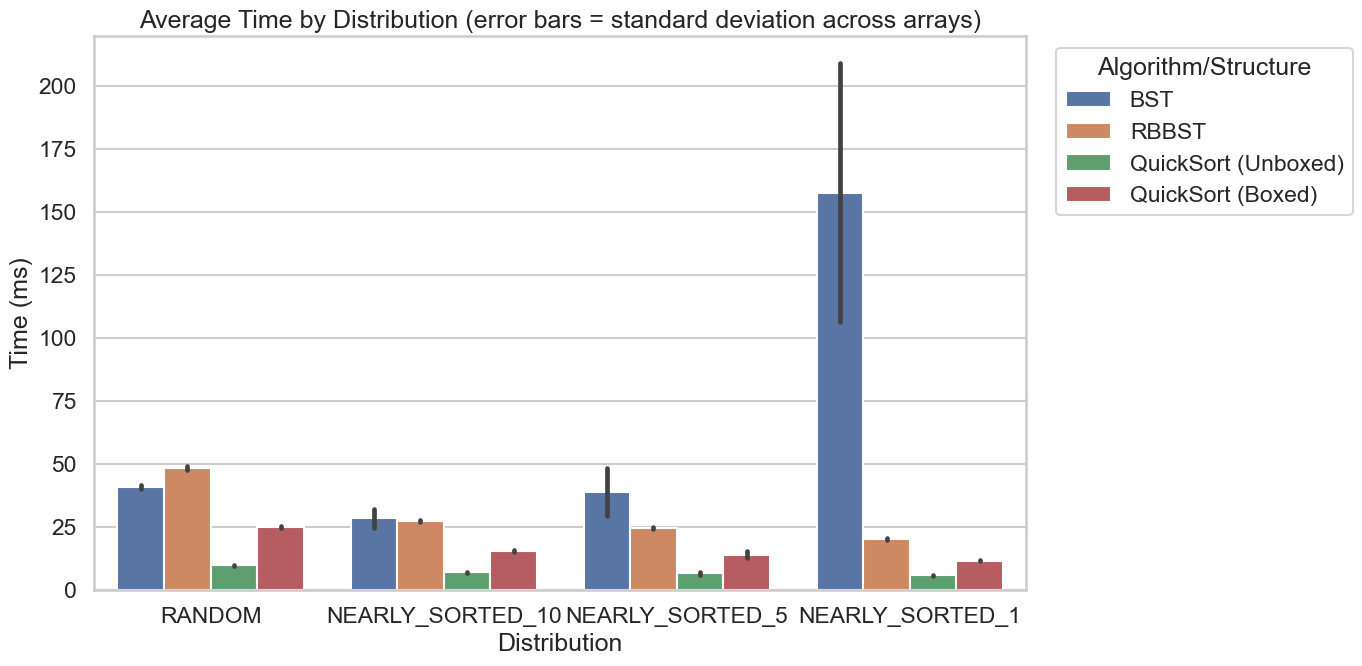

In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=focus_df,
    x='distribution',
    y='mean',
    hue='algorithm',
    estimator=np.mean,
    errorbar='sd',
    order=distribution_order,
    hue_order=algorithm_order,
)
                "from matplotlib.colors import TwoSlopeNorm",
                "",
                "# Speed score vs BST per distribution (score > 1 means faster than BST, < 1 slower).",
                "baseline = (",
                "    summary[summary['algorithm'] == 'BST'][['distribution', 'mean']]",
                "    .rename(columns={'mean': 'bst_mean'})",
                ")",
                "",
                "relative = summary.merge(baseline, on='distribution', how='left')",
                "relative['speed_score_vs_bst'] = relative['bst_mean'] / relative['mean']",
                "",
                "heat = (",
                "    relative.pivot(index='algorithm', columns='distribution', values='speed_score_vs_bst')",
                "    .reindex(algorithm_order)",
                ")",
                "",
                "vmin = float(np.nanmin(heat.values))",
                "vmax = float(np.nanmax(heat.values))",
                "norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)",
                "",
                "plt.figure(figsize=(12, 5.5))",
                "ax = sns.heatmap(",
                "    heat,",
                "    annot=True,",
                "    fmt='.2f',",
                "    cmap='RdYlGn',",
                "    norm=norm,",
                "    linewidths=1,",
                "    linecolor='white',",
                "    square=False,",
                "    cbar_kws={'label': 'BST time / algorithm time (higher is better)'}",
                ")",
                "ax.set_title('Relative Performance vs BST', pad=12, fontweight='bold')",
                "ax.set_xlabel('Distribution')",
                "ax.set_ylabel('Algorithm/Structure')",
                "ax.tick_params(axis='x', rotation=18)",
                "ax.tick_params(axis='y', rotation=0)",
                "ax.collections[0].colorbar.ax.axhline(1.0, color='black', linewidth=1)",
                "ax.text(",
                "    0.5, -0.22,",
                "    'Values above 1.00 mean the algorithm is faster than BST for that distribution.',",
                "    transform=ax.transAxes,",
                "    ha='center',",
                "    va='top',",
                "    fontsize=10",
                ")",
                "plt.tight_layout()",
                "plt.show()",
                "",
                "display(relative.sort_values(['distribution', 'speed_score_vs_bst'], ascending=[True, False]))"
ax.set_xlabel('Distribution')
ax.set_ylabel('Time (ms)')
plt.legend(title='Algorithm/Structure', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

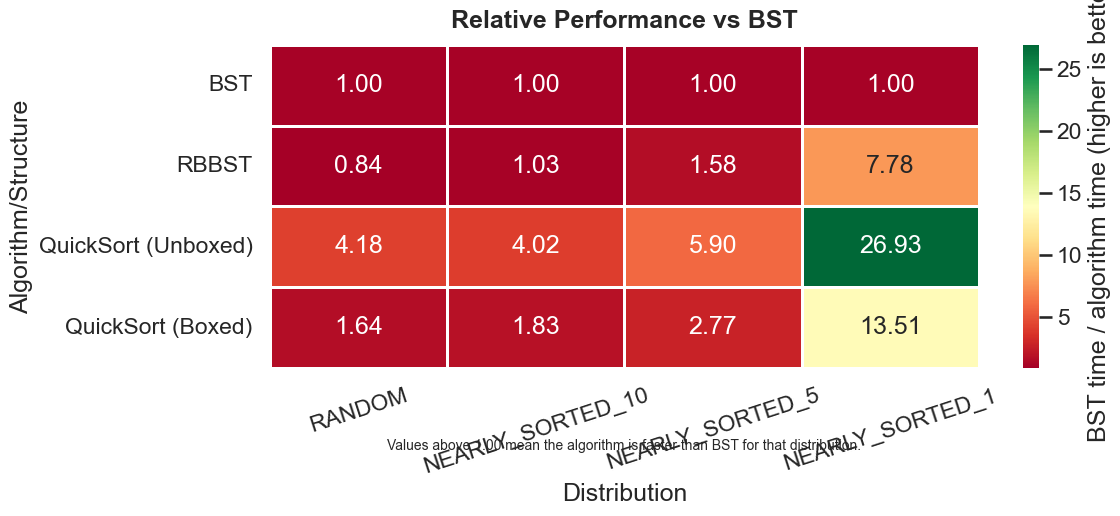

,distribution,algorithm,count,mean,median,std,min,max,cv_pct,bst_mean,speed_score_vs_bst
0,RANDOM,QuickSort (Unboxed),20,9.756542,9.703700,0.166409,9.557690,9.964410,1.705618,40.810692,4.182905
1,RANDOM,QuickSort (Boxed),20,24.927670,25.030862,0.381568,24.194305,25.471375,1.530701,40.810692,1.637164
2,RANDOM,BST,20,40.810692,40.730267,0.766767,39.818320,43.213445,1.878839,40.810692,1.000000
3,RANDOM,RBBST,20,48.435294,48.352528,0.825358,46.933400,50.119845,1.704043,40.810692,0.842582
4,NEARLY_SORTED_10,QuickSort (Unboxed),20,7.075695,7.075997,0.108313,6.913310,7.208160,1.530770,28.415776,4.015970
5,NEARLY_SORTED_10,QuickSort (Boxed),20,15.511927,15.479807,0.223784,15.118780,15.806210,1.442659,28.415776,1.831866
6,NEARLY_SORTED_10,RBBST,20,27.480982,27.368415,0.424096,26.955325,28.182465,1.543236,28.415776,1.034016
7,NEARLY_SORTED_10,BST,20,28.415776,29.017640,3.903876,22.345225,40.038650,13.738411,28.415776,1.000000
8,NEARLY_SORTED_5,QuickSort (Unboxed),20,6.579045,6.446632,0.548686,6.326880,8.865700,8.339899,38.784954,5.895226
9,NEARLY_SORTED_5,QuickSort (Boxed),20,14.001985,13.668467,1.394826,13.290630,19.851050,9.961632,38.784954,2.769961



LaTeX for relative performance table:

\begin{table}[htbp]
\centering
\caption{Relative performance vs BST by algorithm and distribution.}
\label{tab:relative\_performance\_vs\_bst}
\begin{tabular}{lllllllllll}
\hline
distribution & algorithm & count & mean & median & std & min & max & cv\_pct & bst\_mean & speed\_score\_vs\_bst \\
\hline
RANDOM & QuickSort (Unboxed) & 20 & 9.757 & 9.704 & 0.166 & 9.558 & 9.964 & 1.706 & 40.811 & 4.183 \\
RANDOM & QuickSort (Boxed) & 20 & 24.928 & 25.031 & 0.382 & 24.194 & 25.471 & 1.531 & 40.811 & 1.637 \\
RANDOM & BST & 20 & 40.811 & 40.730 & 0.767 & 39.818 & 43.213 & 1.879 & 40.811 & 1.000 \\
RANDOM & RBBST & 20 & 48.435 & 48.353 & 0.825 & 46.933 & 50.120 & 1.704 & 40.811 & 0.843 \\
NEARLY\_SORTED\_10 & QuickSort (Unboxed) & 20 & 7.076 & 7.076 & 0.108 & 6.913 & 7.208 & 1.531 & 28.416 & 4.016 \\
NEARLY\_SORTED\_10 & QuickSort (Boxed) & 20 & 15.512 & 15.480 & 0.224 & 15.119 & 15.806 & 1.443 & 28.416 & 1.832 \\
NEARLY\_SORTED\_10 & RBBST & 20 & 27.481

In [31]:
# Speed score vs BST per distribution (score > 1 means faster than BST, < 1 slower).
baseline = (
    summary[summary['algorithm'] == 'BST'][['distribution', 'mean']]
    .rename(columns={'mean': 'bst_mean'})
)

relative = summary.merge(baseline, on='distribution', how='left')
relative['speed_score_vs_bst'] = relative['bst_mean'] / relative['mean']

heat = relative.pivot(index='algorithm', columns='distribution', values='speed_score_vs_bst').reindex(algorithm_order)

plt.figure(figsize=(12, 5.5))
ax = sns.heatmap(
    heat,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=1,
    linecolor='white',
    square=False,
    cbar_kws={'label': 'BST time / algorithm time (higher is better)'}
)
ax.set_title('Relative Performance vs BST', pad=12, fontweight='bold')
ax.set_xlabel('Distribution')
ax.set_ylabel('Algorithm/Structure')
ax.tick_params(axis='x', rotation=18)
ax.tick_params(axis='y', rotation=0)
ax.text(
    0.5,
    -0.22,
    'Values above 1.00 mean the algorithm is faster than BST for that distribution.',
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=10
)
plt.tight_layout()
plt.show()

display(relative.sort_values(['distribution', 'speed_score_vs_bst'], ascending=[True, False]))

relative_latex = df_to_latex(
    relative.sort_values(['distribution', 'speed_score_vs_bst'], ascending=[True, False]),
    caption='Relative performance vs BST by algorithm and distribution.',
    label='tab:relative_performance_vs_bst',
    index=False,
    float_digits=3,
)
print('\nLaTeX for relative performance table:\n')
print(relative_latex)

In [32]:
# Auto-generated quick conclusions from SortBench focus set.
winners = (
    focus_df.groupby(['distribution', 'algorithm'])['mean']
    .mean()
    .reset_index()
    .sort_values(['distribution', 'mean'])
)

best_per_distribution = winners.groupby('distribution', as_index=False).first()

overall = winners.groupby('algorithm', as_index=False)['mean'].mean().sort_values('mean')

print('Best algorithm/structure per distribution (lower mean is better):')
display(best_per_distribution)

print('Overall average ranking across distributions:')
display(overall)

best_latex = df_to_latex(
    best_per_distribution,
    caption='Best algorithm or structure per distribution based on mean runtime.',
    label='tab:sortbench_best_per_distribution',
    index=False,
    float_digits=3,
)
overall_latex = df_to_latex(
    overall,
    caption='Overall average ranking across distributions based on mean runtime.',
    label='tab:sortbench_overall_ranking',
    index=False,
    float_digits=3,
)
print('\nLaTeX for best-per-distribution table:\n')
print(best_latex)
print('\nLaTeX for overall ranking table:\n')
print(overall_latex)

Best algorithm/structure per distribution (lower mean is better):


,distribution,algorithm,mean
0,RANDOM,QuickSort (Unboxed),9.756542
1,NEARLY_SORTED_10,QuickSort (Unboxed),7.075695
2,NEARLY_SORTED_5,QuickSort (Unboxed),6.579045
3,NEARLY_SORTED_1,QuickSort (Unboxed),5.855943


Overall average ranking across distributions:


,algorithm,mean
2,QuickSort (Unboxed),7.316806
3,QuickSort (Boxed),16.527344
1,RBBST,30.195715
0,BST,66.425158



LaTeX for best-per-distribution table:

\begin{table}[htbp]
\centering
\caption{Best algorithm or structure per distribution based on mean runtime.}
\label{tab:sortbench\_best\_per\_distribution}
\begin{tabular}{lll}
\hline
distribution & algorithm & mean \\
\hline
RANDOM & QuickSort (Unboxed) & 9.757 \\
NEARLY\_SORTED\_10 & QuickSort (Unboxed) & 7.076 \\
NEARLY\_SORTED\_5 & QuickSort (Unboxed) & 6.579 \\
NEARLY\_SORTED\_1 & QuickSort (Unboxed) & 5.856 \\
\hline
\end{tabular}
\end{table}

LaTeX for overall ranking table:

\begin{table}[htbp]
\centering
\caption{Overall average ranking across distributions based on mean runtime.}
\label{tab:sortbench\_overall\_ranking}
\begin{tabular}{ll}
\hline
algorithm & mean \\
\hline
QuickSort (Unboxed) & 7.317 \\
QuickSort (Boxed) & 16.527 \\
RBBST & 30.196 \\
BST & 66.425 \\
\hline
\end{tabular}
\end{table}
